In [ ]:
# Лабораторна робота 3
# Виконав: Байков Олександр

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [ ]:
# Завантаження датасету
from google.colab import files
uploaded = files.upload()

Saving spotify-2023.csv to spotify-2023.csv


In [ ]:
df = pd.read_csv("spotify-2023.csv", encoding='latin1')


In [ ]:
df['streams'] = pd.to_numeric(df['streams'].astype(str).str.replace(',', ''), errors='coerce')

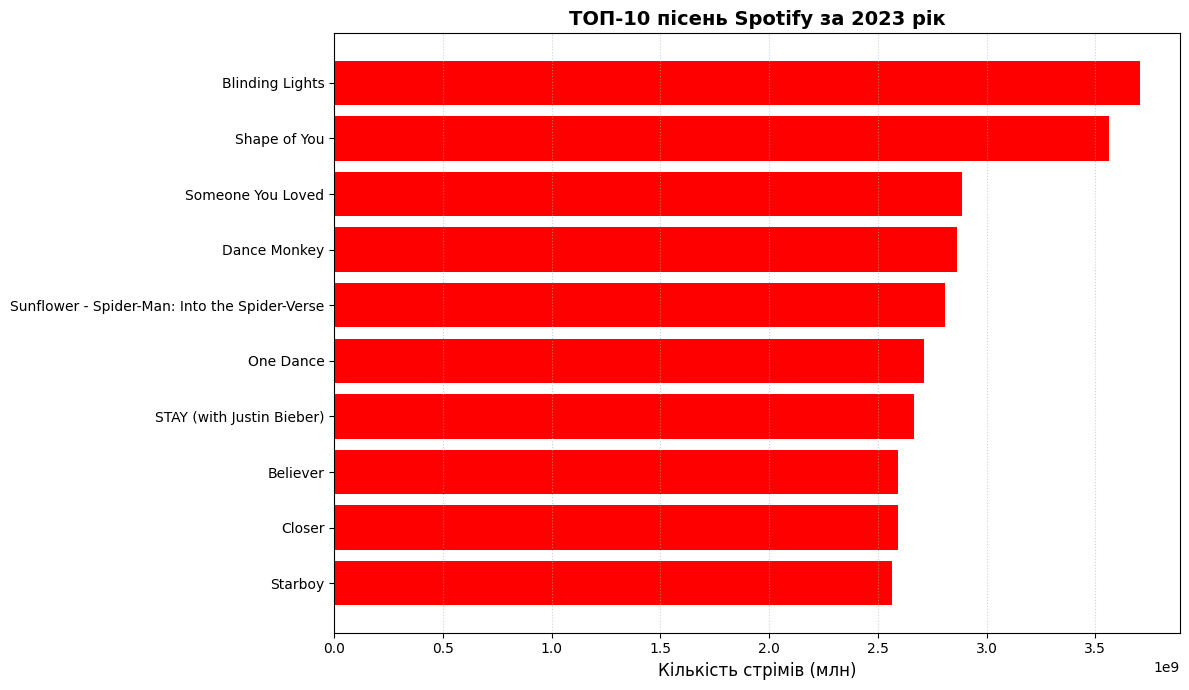

In [ ]:
# Завдання 1
top_10_songs = df.nlargest(10, 'streams')
plt.figure(figsize=(12,7))
plt.barh(top_10_songs['track_name'], top_10_songs['streams'], color='red')
plt.xlabel('Кількість стрімів (млн)', fontsize=12)
plt.title('ТОП-10 пісень Spotify за 2023 рік', fontsize=14, weight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

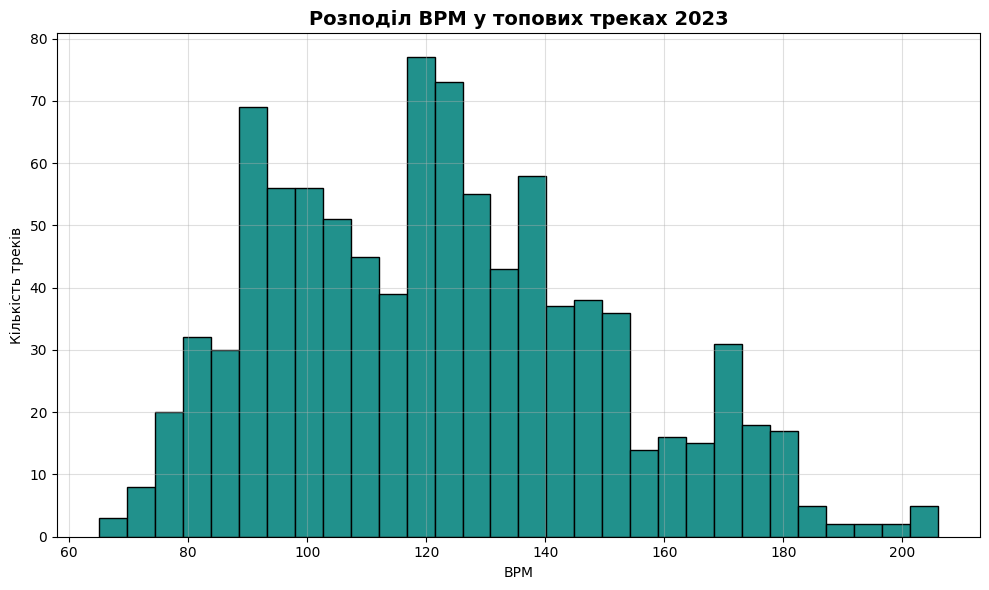

In [ ]:
# Завдання 2
plt.figure(figsize=(10,6))
plt.hist(df['bpm'], bins=30, color=cm.viridis(0.5), edgecolor='black')
plt.title('Розподіл BPM у топових треках 2023', fontsize=14, weight='bold')
plt.xlabel('BPM')
plt.ylabel('Кількість треків')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Завдання 3
# У мене чомусь не вийшло зробити це завдання.


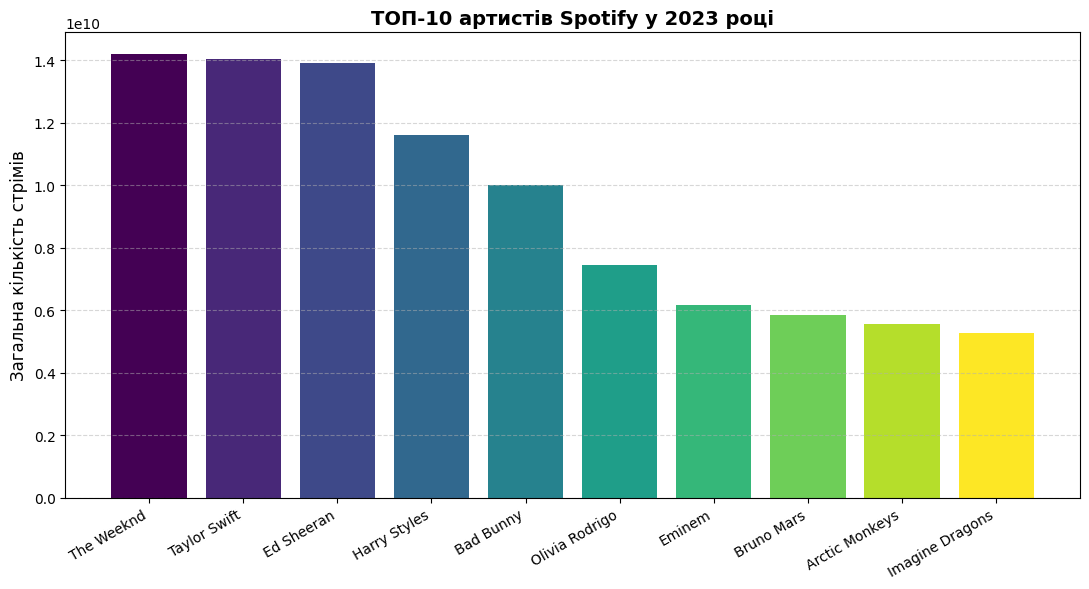

In [ ]:
# Завдання 4
top_artists = df.groupby('artist(s)_name')['streams'].sum().nlargest(10)
artist_colors = cm.viridis(np.linspace(0, 1, len(top_artists)))
plt.figure(figsize=(11,6))
plt.bar(top_artists.index, top_artists.values, color=artist_colors)
plt.ylabel('Загальна кількість стрімів', fontsize=12)
plt.title('ТОП-10 артистів Spotify у 2023 році', fontsize=14, weight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


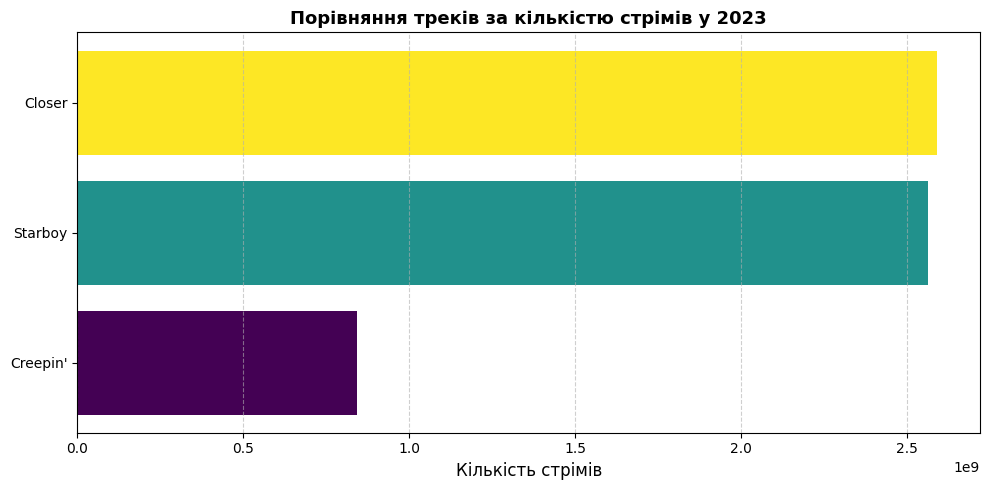

In [ ]:
# Завдання 5
tracks_to_compare = ['Closer', 'Creepin\'', 'Starboy']
comparison = df[df['track_name'].isin(tracks_to_compare)].sort_values('streams', ascending=True)
track_colors = cm.viridis(np.linspace(0, 1, len(comparison)))
plt.figure(figsize=(10,5))
plt.barh(comparison['track_name'], comparison['streams'], color=track_colors)
plt.xlabel('Кількість стрімів', fontsize=12)
plt.title('Порівняння треків за кількістю стрімів у 2023', fontsize=13, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

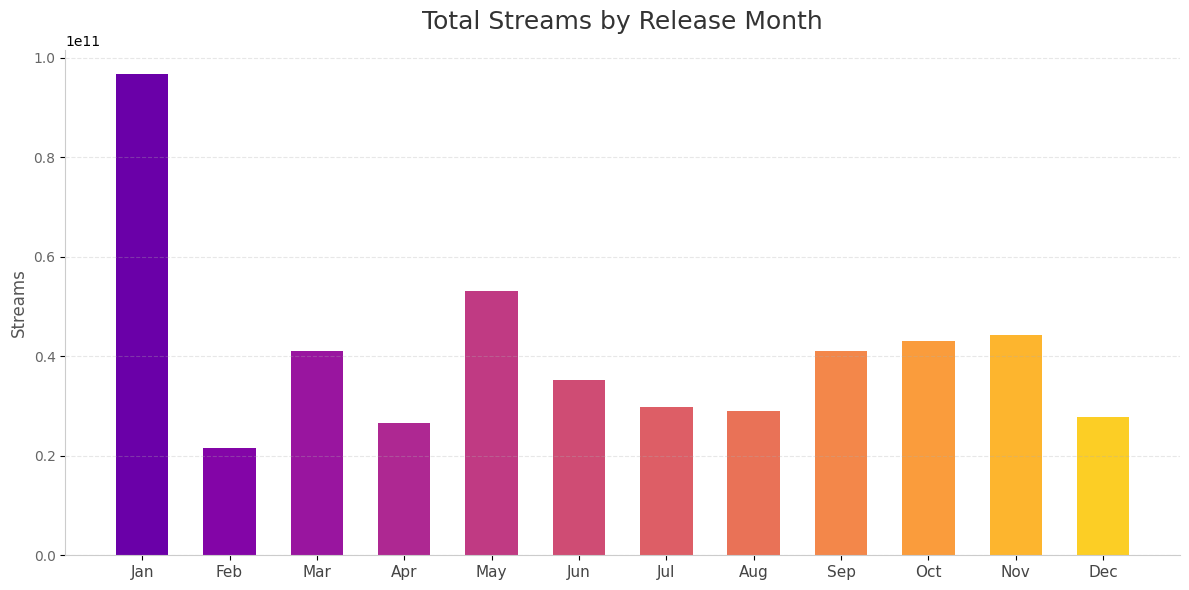

In [ ]:
# Поексперементуйте із стильовим оформленням графіка.
month_streams = df.groupby('released_month')['streams'].sum().sort_index()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = cm.plasma(np.linspace(0.2, 0.9, 12))
plt.figure(figsize=(12,6), facecolor='white')
bars = plt.bar(month_labels, month_streams, color=colors, width=0.6)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#CCCCCC')
plt.gca().spines['bottom'].set_color('#CCCCCC')
plt.title('Total Streams by Release Month', fontsize=18, weight='light', color='#333333', pad=15)
plt.ylabel('Streams', fontsize=12, color='#555555')
plt.xticks(fontsize=11, color='#444444')
plt.yticks(fontsize=10, color='#666666')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

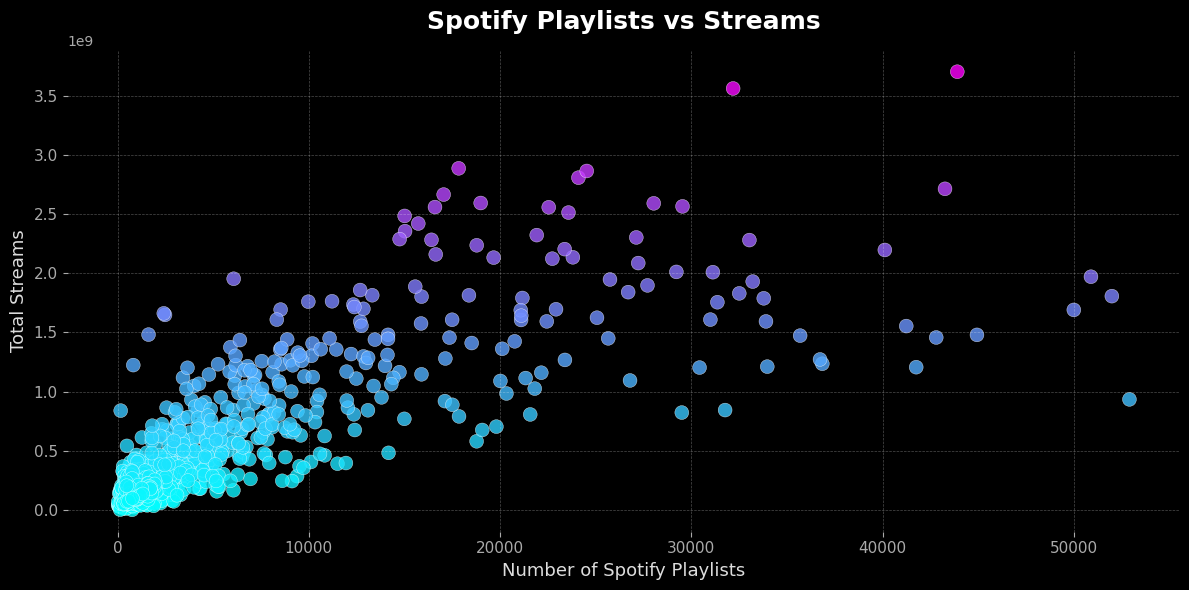

In [ ]:
# Поексперементуйте із стильовим оформленням графіка.
plt.style.use('dark_background')  # темна тема
plt.figure(figsize=(12,6))
colors = cm.cool(df['streams'] / df['streams'].max())
plt.scatter(
    df['in_spotify_playlists'],
    df['streams'],
    c=colors,
    s=100,
    alpha=0.8,
    edgecolors='white',
    linewidths=0.3
)

plt.title('Spotify Playlists vs Streams', fontsize=18, weight='bold', color='white', pad=15)
plt.xlabel('Number of Spotify Playlists', fontsize=13, color='#DDDDDD')
plt.ylabel('Total Streams', fontsize=13, color='#DDDDDD')
plt.grid(visible=True, linestyle='--', linewidth=0.5, alpha=0.3)
plt.tick_params(colors='#AAAAAA', labelsize=11)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()